In [5]:
# %% [0] install
%pip install "paddleocr==2.10.0" paddlepaddle matplotlib
%pip install -q easyocr opencv-python-headless pillow

In [6]:
# %% [A] traQ fetch (messages + images) + save images
import os, re, io
import requests
from PIL import Image
import getpass

messageIds = [
    "019b2a64-eebc-7815-84c5-e384fabc495c",
    "019a48ff-b175-783c-93fc-b4ec6731dde5",
    "019bb6b8-5c57-7d1f-8b93-297c8e6c7827",
    "019bb5c0-5409-7b3b-ba9b-07449030364a",
    "019bd043-d86c-79b8-9cf1-11351a482267",
    "0197c4ef-8be2-792e-922b-c498b6948775",
    "01963951-0f55-75b5-a53b-07f467ad9051",
    "0195be37-dea6-7902-8d04-e46185873108",
    "019bde55-0ca0-7d7a-95ab-0a1c3bf5eeaa",
    "019bde55-b166-7d7b-b290-2f049f72fe08",
    "019bbd0d-5e27-77b2-8494-42499697c033",
    "019bde84-1609-7dc5-b8fc-f2c77bcdb005",
    "019bdeb4-6ec8-7e0e-b773-3bec85c35584",
    "019bb65e-9263-7c89-b123-95389f4414cd",
    "019b8cea-695d-7047-aafb-793c58d25eff",
]

r_session = getpass.getpass("r_session を入力してください（表示されません）: ").strip()
if not r_session:
    raise RuntimeError("r_session が空です")

BASE_URL = "https://q.trap.jp/api/v3"
_FILE_URL_RE = re.compile(r"https?://q\.trap\.jp/files/([0-9a-fA-F-]+)")

def _get_session() -> requests.Session:
    s = requests.Session()
    s.cookies.set("r_session", r_session)
    return s

def get_messages_and_images(message_ids):
    messages, images = [], []
    with _get_session() as session:
        for mid in message_ids:
            resp = session.get(f"{BASE_URL}/messages/{mid}")
            resp.raise_for_status()
            content = resp.json()["content"]

            file_ids = _FILE_URL_RE.findall(content)
            imgs = []
            for fid in file_ids:
                r = session.get(f"{BASE_URL}/files/{fid}")
                r.raise_for_status()
                try:
                    imgs.append(Image.open(io.BytesIO(r.content)).convert("RGB"))
                except Exception as e:
                    print(f"[skip] not an image fileId={fid}: {e}")

            text = _FILE_URL_RE.sub("", content).strip()
            messages.append(text)
            images.append(imgs)

    return messages, images

messages, images = get_messages_and_images(messageIds)
print("messages:", len(messages))
print("msgs with images:", sum(1 for x in images if len(x) > 0))

SAVE_DIR = "/content/traq_images"
os.makedirs(SAVE_DIR, exist_ok=True)

records = []
for mid, msg_text, imgs in zip(messageIds, messages, images):
    for j, im in enumerate(imgs):
        path = os.path.join(SAVE_DIR, f"{mid}_{j}.png")
        im.save(path)
        records.append({
            "messageId": mid,
            "image_index": j,
            "message_text": msg_text,
            "image_path": path,
        })

print("saved images:", len(records))
print("example:", records[0] if records else None)

messages: 15
msgs with images: 15
saved images: 20
example: {'messageId': '019b2a64-eebc-7815-84c5-e384fabc495c', 'image_index': 0, 'message_text': ':tada: 味処まるたかエグい\nhttps://icttoracon.net/archives/10329', 'image_path': '/content/traq_images/019b2a64-eebc-7815-84c5-e384fabc495c_0.png'}


In [ ]:
# %% [B] OCR init (Easy vs Paddle)
import time, json, html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import easyocr
from paddleocr import PaddleOCR
from IPython.display import display, HTML

UPSCALE = 2
CONF_TH = 0.4

# 言語
LANG_MODE = "ja"   # "en" or "ja"
EASYOCR_LANGS = ["en"] if LANG_MODE == "en" else ["ja", "en"]
PADDLE_LANG  = "en" if LANG_MODE == "en" else "japan"

# EasyOCR
easy_reader = easyocr.Reader(EASYOCR_LANGS, gpu=True, download_enabled=True)

# Paddleの拾いすぎ抑制（ここを調整）
PADDLE_DET_DB_BOX_THRESH = 0.75  # 0.7〜0.85くらいで調整（上げるほど拾わない）
PADDLE_DROP_SCORE        = 0.4  # 0.7〜0.9くらいで調整（上げるほど低信頼を捨てる）

def init_paddle():
    # v3っぽい引数（TypeErrorならv2へ）
    try:
        return PaddleOCR(
            lang=PADDLE_LANG,
            use_doc_orientation_classify=False,
            use_doc_unwarping=False,
            use_textline_orientation=True,
            det_db_box_thresh=PADDLE_DET_DB_BOX_THRESH,
            drop_score=PADDLE_DROP_SCORE,
        )
    except TypeError:
        return PaddleOCR(
            lang=PADDLE_LANG,
            use_angle_cls=True,
            det_db_box_thresh=PADDLE_DET_DB_BOX_THRESH,
            drop_score=PADDLE_DROP_SCORE,
        )

paddle_ocr = init_paddle()
print("OCR engines initialized: EasyOCR + PaddleOCR")

[2026/03/05 13:58:35] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/ml/Multilingual_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.4, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/japan/japan_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_n

[2026/03/05 13:58:37] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 13:58:37] ppocr DEBUG: dt_boxes num : 52, elapsed : 0.11273932456970215
[2026/03/05 13:58:37] ppocr DEBUG: rec_res num  : 52, elapsed : 0.4955570697784424
[2026/03/05 13:58:39] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 13:58:39] ppocr DEBUG: dt_boxes num : 52, elapsed : 0.09997916221618652
[2026/03/05 13:58:39] ppocr DEBUG: rec_res num  : 52, elapsed : 0.54038405418396


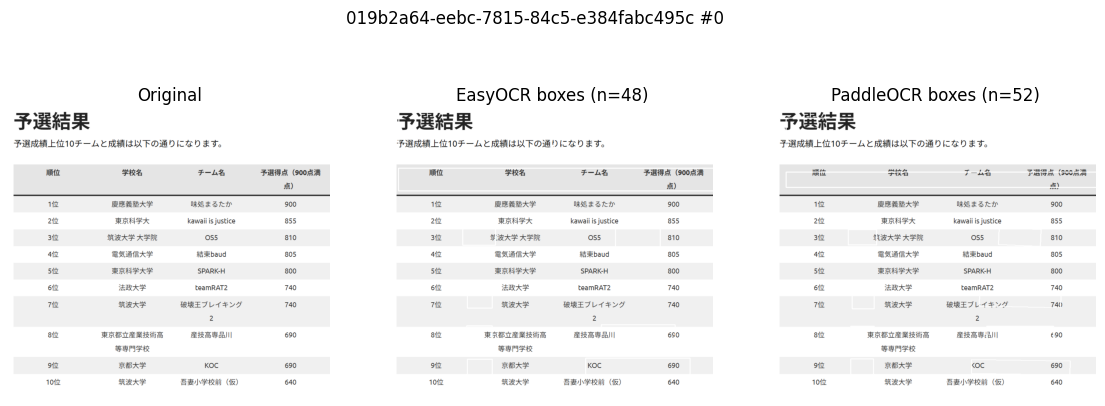

[2026/03/05 13:58:44] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 13:58:44] ppocr DEBUG: dt_boxes num : 57, elapsed : 0.15386748313903809
[2026/03/05 13:58:45] ppocr DEBUG: rec_res num  : 57, elapsed : 0.4832427501678467


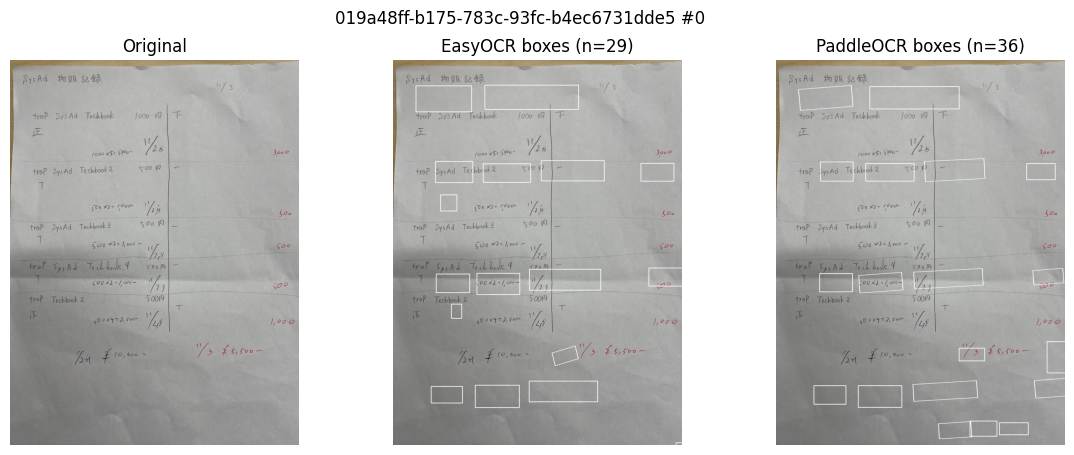

[2026/03/05 13:58:48] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 13:58:49] ppocr DEBUG: dt_boxes num : 13, elapsed : 0.13194513320922852
[2026/03/05 13:58:49] ppocr DEBUG: rec_res num  : 13, elapsed : 0.25333523750305176


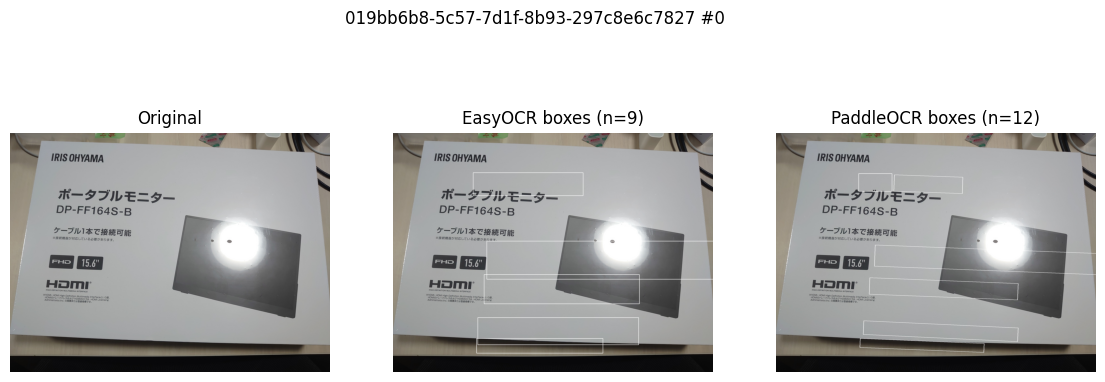

[2026/03/05 13:58:56] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 13:58:56] ppocr DEBUG: dt_boxes num : 81, elapsed : 0.10050487518310547
[2026/03/05 13:58:57] ppocr DEBUG: rec_res num  : 81, elapsed : 0.8484444618225098


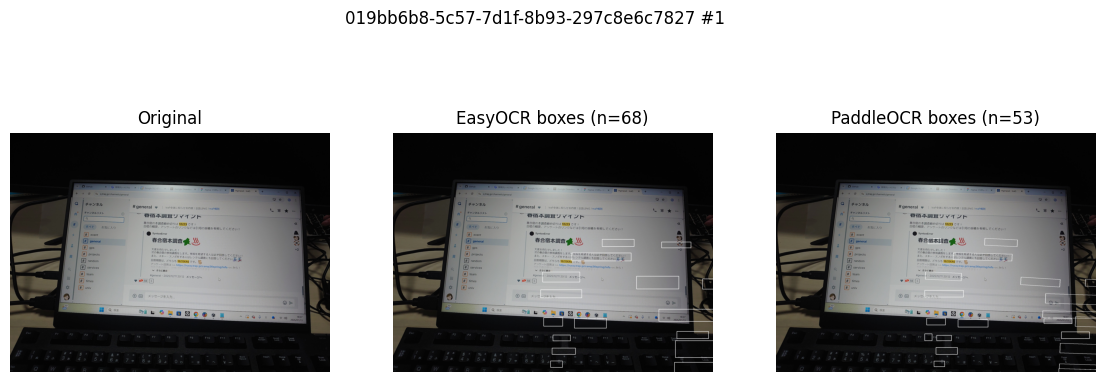

[2026/03/05 13:58:59] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 13:58:59] ppocr DEBUG: dt_boxes num : 12, elapsed : 0.08561491966247559
[2026/03/05 13:58:59] ppocr DEBUG: rec_res num  : 12, elapsed : 0.1764364242553711


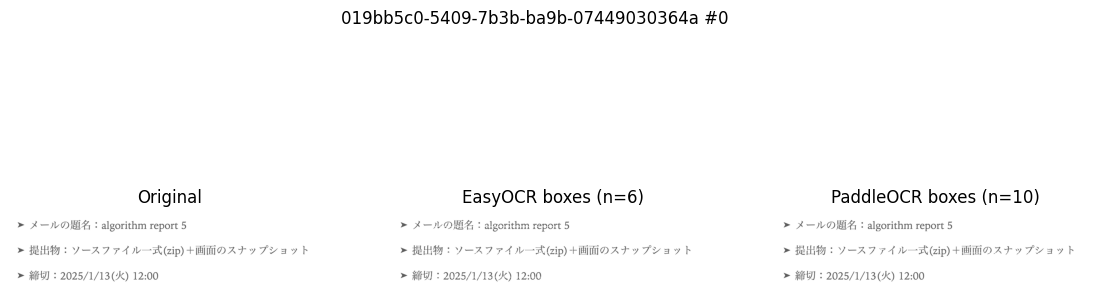

[2026/03/05 13:59:00] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 13:59:00] ppocr DEBUG: dt_boxes num : 21, elapsed : 0.08759713172912598
[2026/03/05 13:59:01] ppocr DEBUG: rec_res num  : 21, elapsed : 0.27553725242614746


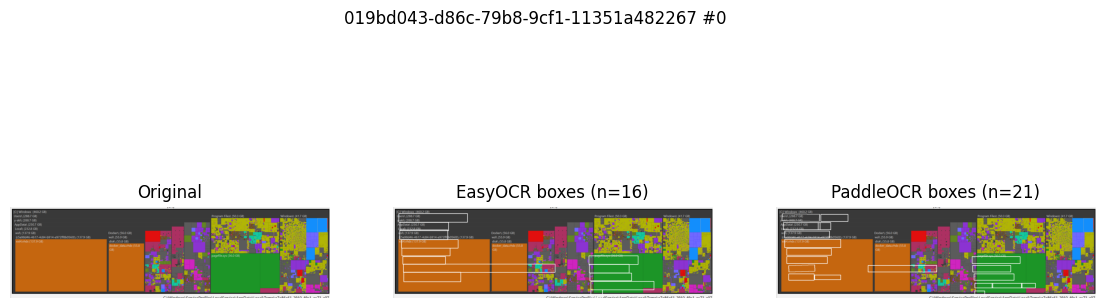

[2026/03/05 13:59:01] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 13:59:01] ppocr DEBUG: dt_boxes num : 7, elapsed : 0.10088920593261719
[2026/03/05 13:59:01] ppocr DEBUG: rec_res num  : 7, elapsed : 0.11790990829467773


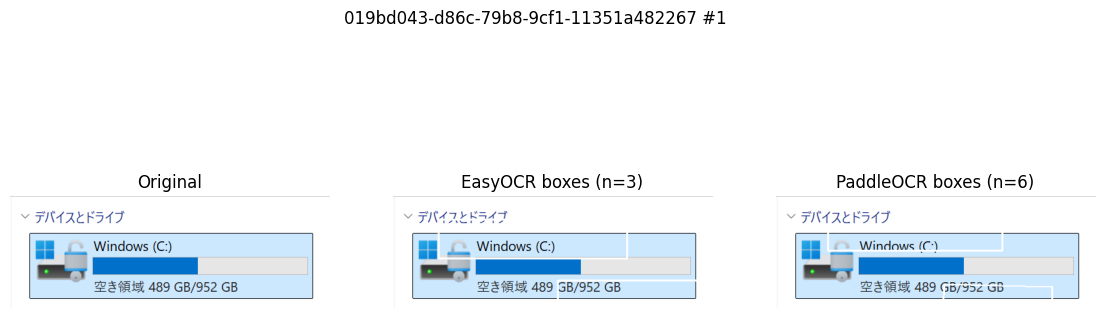

[2026/03/05 13:59:01] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 13:59:02] ppocr DEBUG: dt_boxes num : 2, elapsed : 0.08747529983520508
[2026/03/05 13:59:02] ppocr DEBUG: rec_res num  : 2, elapsed : 0.09236860275268555


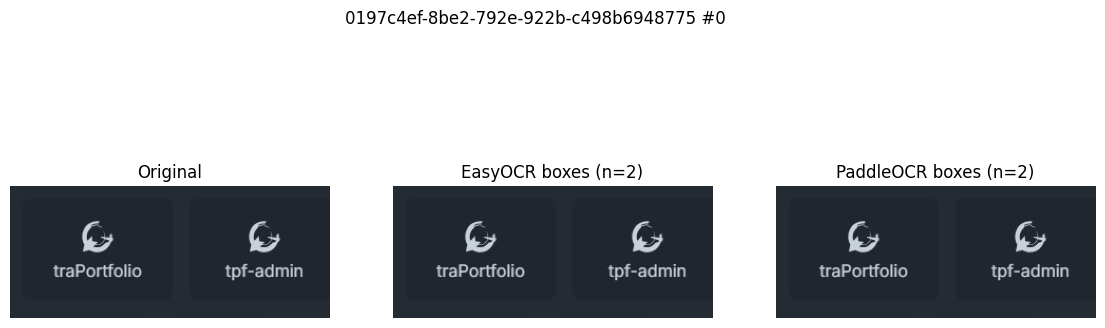

[2026/03/05 13:59:06] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 13:59:07] ppocr DEBUG: dt_boxes num : 2, elapsed : 0.0902247428894043
[2026/03/05 13:59:07] ppocr DEBUG: rec_res num  : 2, elapsed : 0.0257718563079834


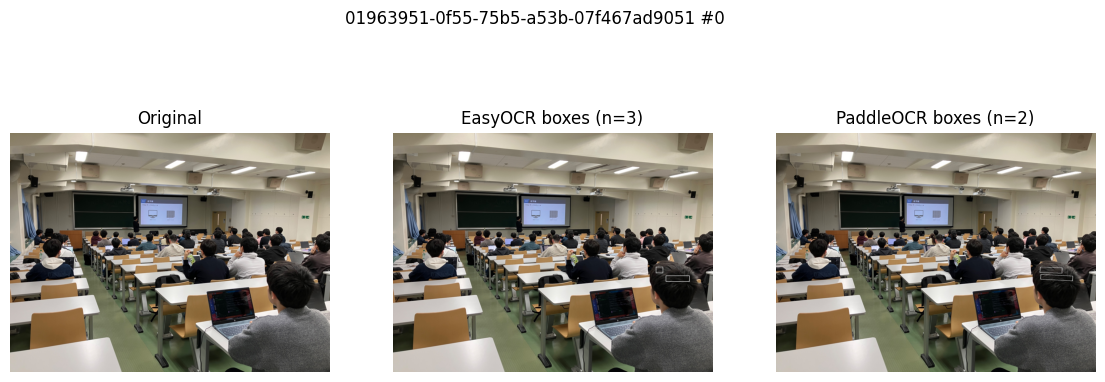

[2026/03/05 13:59:13] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 13:59:13] ppocr DEBUG: dt_boxes num : 13, elapsed : 0.07160472869873047
[2026/03/05 13:59:14] ppocr DEBUG: rec_res num  : 13, elapsed : 0.2551290988922119


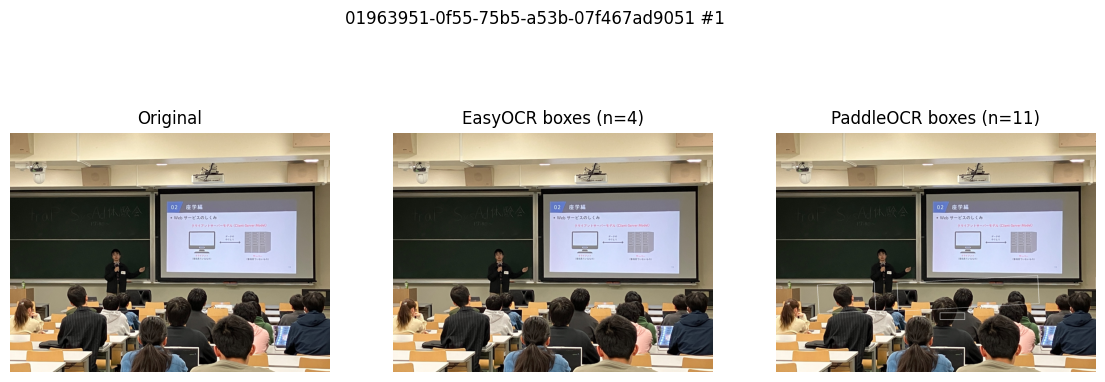

[2026/03/05 13:59:19] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 13:59:20] ppocr DEBUG: dt_boxes num : 5, elapsed : 0.0640859603881836
[2026/03/05 13:59:20] ppocr DEBUG: rec_res num  : 5, elapsed : 0.0988919734954834


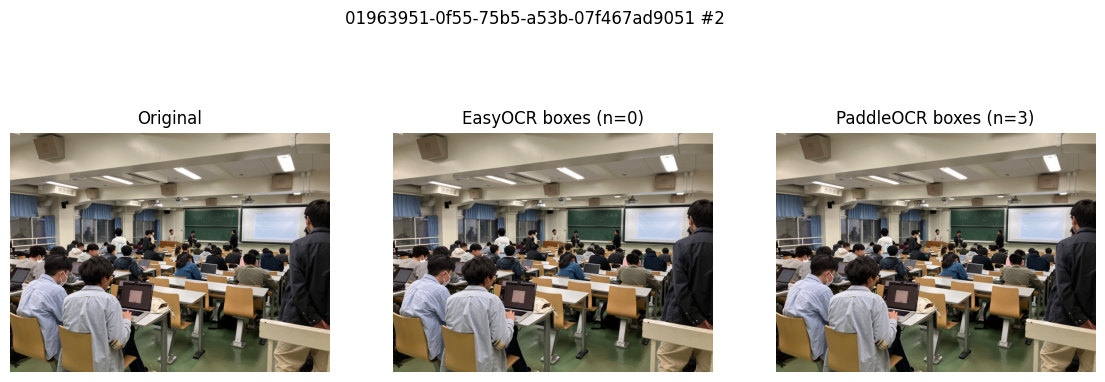

[2026/03/05 13:59:21] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 13:59:21] ppocr DEBUG: dt_boxes num : 17, elapsed : 0.09474873542785645
[2026/03/05 13:59:21] ppocr DEBUG: rec_res num  : 17, elapsed : 0.24138450622558594


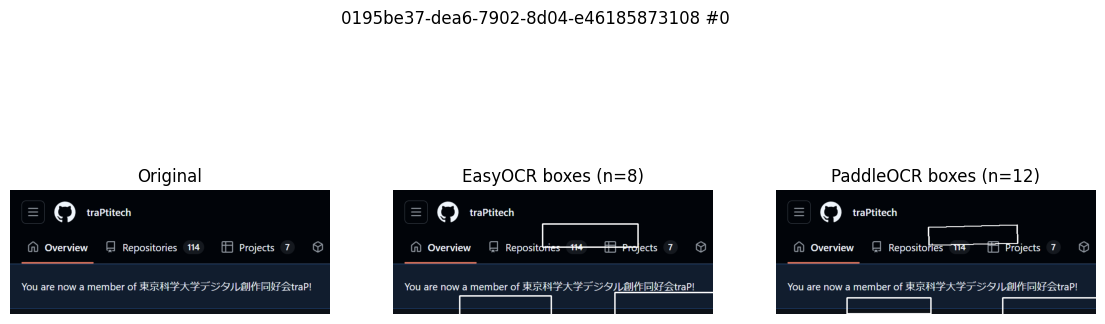

[2026/03/05 13:59:24] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 13:59:25] ppocr DEBUG: dt_boxes num : 51, elapsed : 0.127685546875
[2026/03/05 13:59:25] ppocr DEBUG: rec_res num  : 51, elapsed : 0.5949807167053223


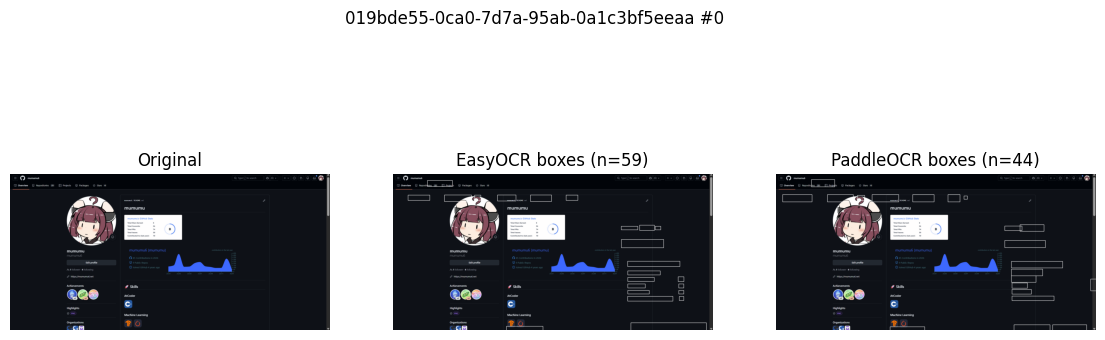

[2026/03/05 13:59:29] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 13:59:29] ppocr DEBUG: dt_boxes num : 88, elapsed : 0.07951760292053223
[2026/03/05 13:59:30] ppocr DEBUG: rec_res num  : 88, elapsed : 1.008469820022583


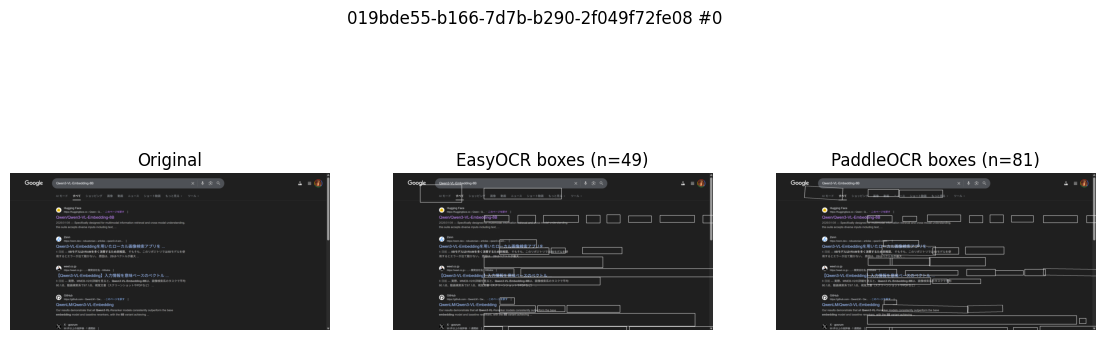

[2026/03/05 13:59:32] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 13:59:32] ppocr DEBUG: dt_boxes num : 11, elapsed : 0.11626648902893066
[2026/03/05 13:59:32] ppocr DEBUG: rec_res num  : 11, elapsed : 0.13382411003112793


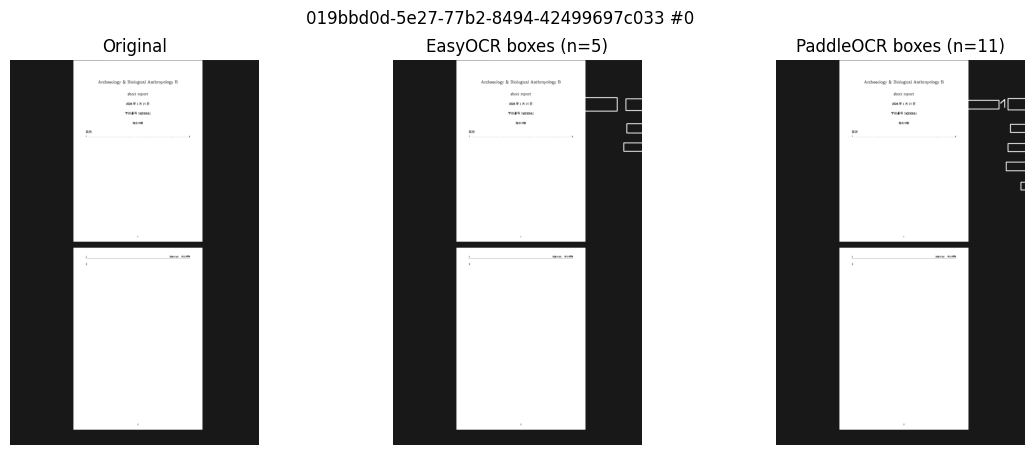

[2026/03/05 13:59:37] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 13:59:37] ppocr DEBUG: dt_boxes num : 24, elapsed : 0.12818074226379395
[2026/03/05 13:59:38] ppocr DEBUG: rec_res num  : 24, elapsed : 0.3251938819885254


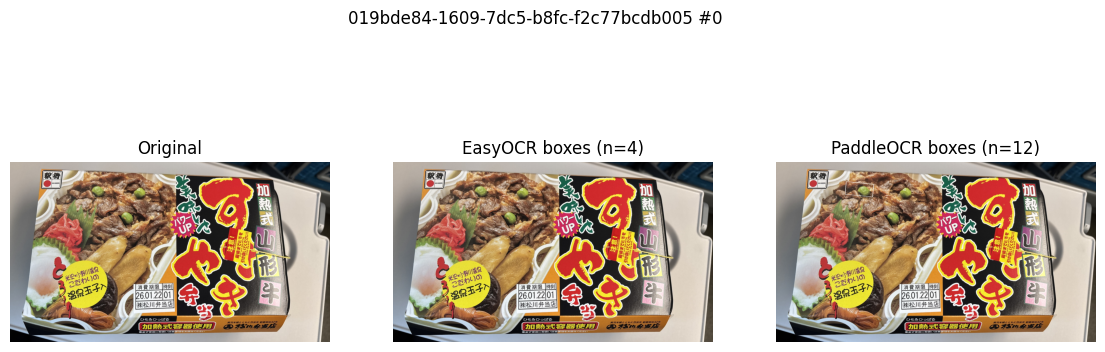

[2026/03/05 13:59:39] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 13:59:40] ppocr DEBUG: dt_boxes num : 4, elapsed : 0.09574031829833984
[2026/03/05 13:59:40] ppocr DEBUG: rec_res num  : 4, elapsed : 0.08513092994689941


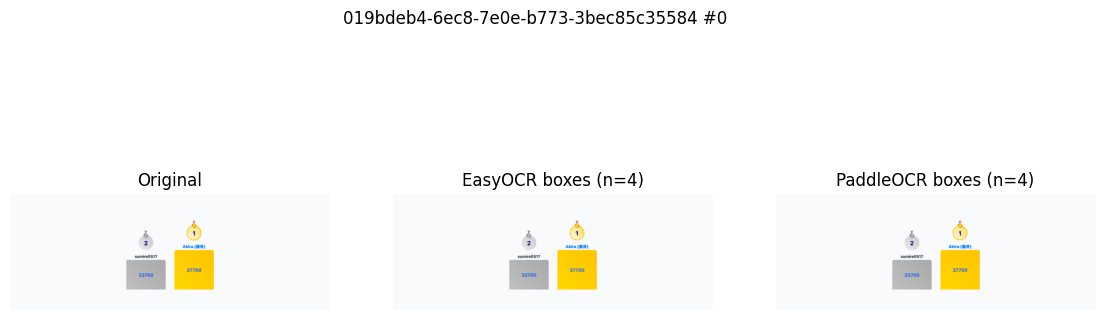

[2026/03/05 13:59:41] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 13:59:41] ppocr DEBUG: dt_boxes num : 31, elapsed : 0.13768482208251953
[2026/03/05 13:59:42] ppocr DEBUG: rec_res num  : 31, elapsed : 0.3641669750213623


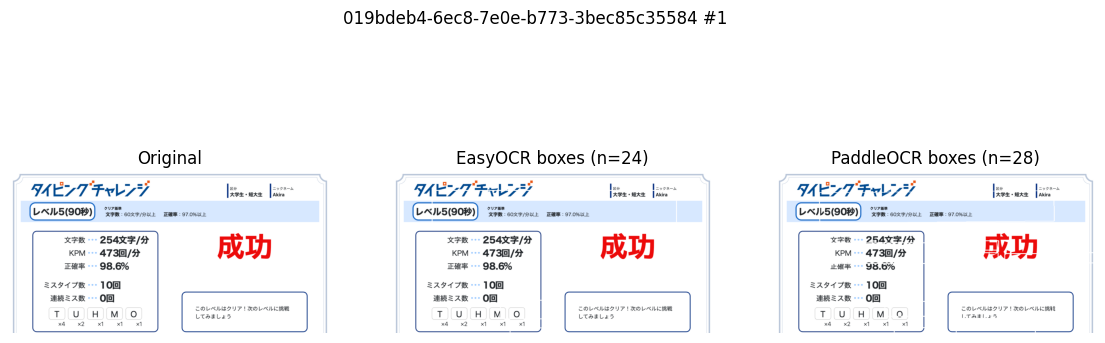

[2026/03/05 13:59:45] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 13:59:46] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.07780265808105469
[2026/03/05 13:59:46] ppocr DEBUG: rec_res num  : 0, elapsed : 9.5367431640625e-07


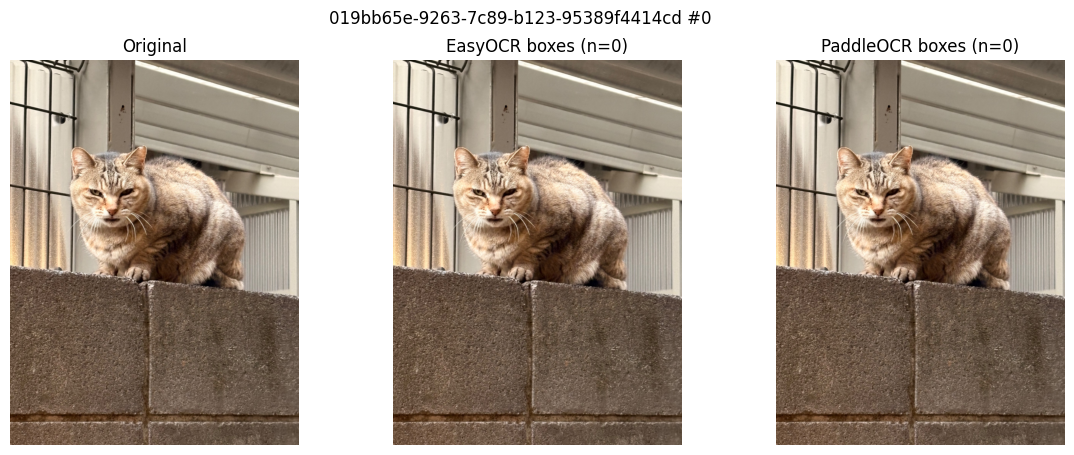

[2026/03/05 13:59:47] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 13:59:48] ppocr DEBUG: dt_boxes num : 33, elapsed : 0.12161755561828613
[2026/03/05 13:59:48] ppocr DEBUG: rec_res num  : 33, elapsed : 0.32369041442871094


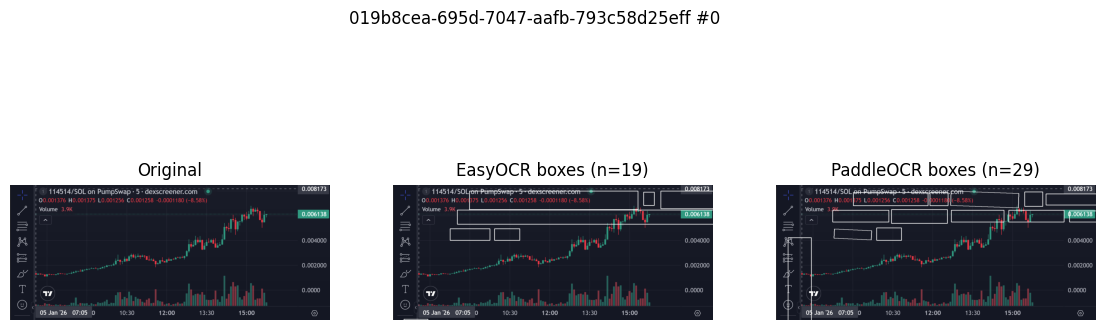

,k,messageId,image_index,easy_sec,paddle_sec,easy_n,paddle_n,easy_mean_conf,paddle_mean_conf,paddle/easy_time,easy_text_head,paddle_text_head
7,8,0197c4ef-8be2-792e-922b-c498b6948775,0,0.050254,0.185584,2,2,0.840306,0.977914,3.692941,taporttolio tpf-admin,traPortfolio tpf-admin
6,7,019bd043-d86c-79b8-9cf1-11351a482267,1,0.078619,0.228746,3,6,0.874467,0.999593,2.909568,デバイスとドライブ Windows (C:) 空き領域 489 GB/952 GB,デバイスとドライブ Windows 空き領域 489 GB/952 GB
11,12,0195be37-dea6-7902-8d04-e46185873108,0,0.186936,0.353134,8,12,0.904256,0.931371,1.889070,traPtitech Overview Repositories 114 Projects ...,traPtitech Overview Repositories 114 1日 Projec...
4,5,019bb5c0-5409-7b3b-ba9b-07449030364a,0,0.316575,0.348403,6,10,0.907364,0.983562,1.100541,メールの題名 algorithmreport5 提出物: ソースファイルー式(zip)十画面...,メールの題名 algorithm report 提出物 :ソースファイルー式 (2iP) 十...
16,17,019bdeb4-6ec8-7e0e-b773-3bec85c35584,0,0.335403,0.316101,4,4,0.778718,0.996164,0.942449,2 sumire0517 37700 33700,Akira (自分) Sumire0517 37700 33700
13,14,019bde55-b166-7d7b-b290-2f049f72fe08,0,1.567481,1.335895,49,81,0.830569,0.970684,0.852256,Google Qwen3-VL-Embedding-8B a Aモード すべて ショッピング...,Google Qwen3-VL Embedding-8B × ＡIモード ショッピング 画像...
17,18,019bdeb4-6ec8-7e0e-b773-3bec85c35584,1,0.728366,0.557612,24,28,0.899379,0.967737,0.765565,タイピンクチャレンジ 区分 ニックネーム 大学生 ・ 短大生 Akira 文字数 KPM 成...,タイピンクチャレンン 区分 ニックネーム 大学生 短大生 Akira レベル5(90秒) ク...
9,10,01963951-0f55-75b5-a53b-07f467ad9051,1,0.921881,0.687125,4,11,0.794170,0.815241,0.745351,02 座学編 Web サービスのしくみ クライアントサーハーモテル (CUent Serer...,02 座学編 シ>八日体験会 Fral Webサービスのしくみ 130 クライアントサーパー...
10,11,01963951-0f55-75b5-a53b-07f467ad9051,2,0.706033,0.519314,0,3,0.000000,0.769260,0.735537,,frap SN休験会 17:30へ
12,13,019bde55-0ca0-7d7a-95ab-0a1c3bf5eeaa,0,1.354258,0.958019,59,44,0.884488,0.934150,0.707412,mumumu6 Type tosearch 8? Overview Repositories...,mumumu6 αType to search + [ｏı overview Reposit...



=== Time summary (seconds) [k>=2] ===
EasyOCR  mean=0.857  p50=0.728  p90=1.569
Paddle   mean=0.584  p50=0.519  p90=1.024

=== Avg boxes [k>=2] ===
EasyOCR  avg_n=16.4
Paddle   avg_n=19.8  (after filtering)

Saved: /content/traq_ocr_easy_vs_paddle.json


In [12]:
# %% [C] Run & compare (Easy vs Paddle) + 横並びテキスト表示
from typing import List, Dict, Any, Tuple


def pil_open_rgb(path: str) -> Image.Image:
    return Image.open(path).convert("RGB")

def poly_to_bbox(poly: List[List[float]]) -> Tuple[float,float,float,float]:
    xs = [p[0] for p in poly]
    ys = [p[1] for p in poly]
    return (min(xs), min(ys), max(xs), max(ys))

def draw_polys(img: Image.Image, items: List[Dict[str,Any]], max_polys: int = 200) -> Image.Image:
    out = img.copy()
    d = ImageDraw.Draw(out)
    for it in items[:max_polys]:
        poly = it["poly"]
        d.line(poly + [poly[0]], width=3)
    return out

def show_compare_easy_paddle(image_path: str, r_easy, r_pad, title: str = ""):
    base = pil_open_rgb(image_path)
    im_easy = draw_polys(base, r_easy["items"])
    im_pad  = draw_polys(base, r_pad["items"])

    plt.figure(figsize=(14, 5))
    for i, (im, name) in enumerate([
        (base, "Original"),
        (im_easy, f"EasyOCR boxes (n={len(r_easy['items'])})"),
        (im_pad,  f"PaddleOCR boxes (n={len(r_pad['items'])})"),
    ], start=1):
        plt.subplot(1, 3, i)
        plt.imshow(im)
        plt.title(name)
        plt.axis("off")
    if title:
        plt.suptitle(title)
    plt.show()

def show_text_side_by_side(rec, r_easy, r_pad, max_chars=3000):
    easy_txt = (r_easy.get("full_text") or "")[:max_chars]
    pad_txt  = (r_pad.get("full_text")  or "")[:max_chars]

    title = f'{rec["messageId"]} #{rec["image_index"]} | Easy {r_easy["seconds"]:.3f}s / Paddle {r_pad["seconds"]:.3f}s'
    meta  = f'boxes: Easy {len(r_easy["items"])} / Paddle {len(r_pad["items"])} (after filtering)'

    display(HTML(f"""
    <div style="margin:10px 0; padding:10px; border:1px solid #ddd; border-radius:8px;">
      <div style="font-weight:700; margin-bottom:6px;">{html.escape(title)}</div>
      <div style="color:#666; margin-bottom:10px;">{html.escape(meta)}</div>
      <div style="display:flex; gap:12px;">
        <div style="flex:1;">
          <div style="font-weight:600; margin-bottom:6px;">EasyOCR</div>
          <pre style="white-space:pre-wrap; word-break:break-word; background:#fafafa; padding:10px; border-radius:6px; border:1px solid #eee; max-height:360px; overflow:auto;">{html.escape(easy_txt)}</pre>
        </div>
        <div style="flex:1;">
          <div style="font-weight:600; margin-bottom:6px;">PaddleOCR</div>
          <pre style="white-space:pre-wrap; word-break:break-word; background:#fafafa; padding:10px; border-radius:6px; border:1px solid #eee; max-height:360px; overflow:auto;">{html.escape(pad_txt)}</pre>
        </div>
      </div>
    </div>
    """))

# ---------- EasyOCR ----------
def run_easyocr(image_path: str, scale=UPSCALE, conf_th=CONF_TH) -> Dict[str, Any]:
    # PILで読み込み→拡大→numpy配列で渡す（後者のocr_pil_imageと同じ流れ）
    base = pil_open_rgb(image_path)
    if scale and scale != 1:
        w, h = base.size
        base = base.resize((w * scale, h * scale), Image.BICUBIC)
    arr = np.array(base)

    t0 = time.perf_counter()
    out = easy_reader.readtext(arr, detail=1, paragraph=False)  # [[bbox4pts], text, conf]
    dt = time.perf_counter() - t0

    items = []
    for bbox, text, conf in out:
        conf = float(conf)
        if conf < conf_th:
            continue
        t = (str(text) or "").strip()
        if not t:
            continue
        poly = [[float(x), float(y)] for x, y in bbox]
        items.append({
            "text": t,
            "conf": conf,
            "poly": poly,
            "bbox": list(map(float, poly_to_bbox(poly))),
        })

    full_text = "\n".join([it["text"] for it in items])
    mean_conf = float(np.mean([it["conf"] for it in items])) if items else 0.0
    return {"engine": "easyocr", "seconds": dt, "items": items, "full_text": full_text, "mean_conf": mean_conf}
# ---------- PaddleOCR (v3/v2 両対応) ----------
def _to_py(x):
    return x.tolist() if hasattr(x, "tolist") else x

def _parse_paddle_v3(pred_result):
    r0 = pred_result[0] if isinstance(pred_result, (list, tuple)) and len(pred_result) > 0 else pred_result

    if hasattr(r0, "json"):
        j = r0.json
        data = j() if callable(j) else j
    elif isinstance(r0, dict):
        data = r0
    else:
        raise TypeError(f"Unexpected PaddleOCR v3 result type: {type(r0)}")

    if isinstance(data, str):
        data = json.loads(data)

    if "res" in data and isinstance(data["res"], dict):
        data = data["res"]

    texts  = data.get("rec_texts", []) or []
    scores = _to_py(data.get("rec_scores", [])) or []
    polys  = _to_py(data.get("rec_polys", None)) or _to_py(data.get("dt_polys", None))

    items = []
    if polys is None:
        return items

    for i, t in enumerate(texts):
        if i >= len(polys):
            break
        poly = polys[i]
        conf = float(scores[i]) if i < len(scores) else 0.0
        poly = [[float(x), float(y)] for x, y in poly]
        items.append({
            "text": t,
            "conf": conf,
            "poly": poly,
            "bbox": list(map(float, poly_to_bbox(poly))),
        })
    return items

# 後処理フィルタ（拾いすぎを軽く抑える）
FILTER_MIN_AREA_RATIO  = 0.00003  # 0.00003〜0.00008 くらいで調整
FILTER_SINGLE_CHAR_CONF = 0.92    # 0.92〜0.97 くらいで調整（上げるほど1文字を捨てる）

def filter_paddle_items(items, img_w, img_h,
                        conf_th=CONF_TH,
                        min_area_ratio=FILTER_MIN_AREA_RATIO,
                        single_char_conf=FILTER_SINGLE_CHAR_CONF):
    min_area = img_w * img_h * min_area_ratio
    kept = []
    for it in items:
        x0,y0,x1,y1 = it["bbox"]
        area = max(0, x1-x0) * max(0, y1-y0)
        text = (it["text"] or "").strip()
        conf = float(it["conf"])

        # 共通 conf 閾値
        if conf < conf_th:
            continue
        # 面積が小さすぎるやつを落とす（拾いすぎ抑制）
        if area < min_area:
            continue
        # 1文字ノイズ抑制（必要ならOFFでもOK）
        if len(text) == 1 and conf < single_char_conf:
            continue

        kept.append(it)
    return kept

# ...existing code...
def _safe_paddle_v2_lines(result):
    # Paddle v2 の返り値ゆらぎを吸収
    if result is None:
        return []
    if isinstance(result, (list, tuple)):
        if len(result) == 0:
            return []
        first = result[0]
        if first is None:
            return []
        if isinstance(first, (list, tuple)):
            return first
        return []
    return []

import tempfile
import os

def run_paddle(image_path: str, scale=UPSCALE) -> Dict[str, Any]:
    # PILで読み込み→拡大→一時ファイルに保存して Paddle に渡す
    base = pil_open_rgb(image_path)
    if scale and scale != 1:
        w, h = base.size
        base = base.resize((w * scale, h * scale), Image.BICUBIC)

    tmp_path = None
    try:
        fd, tmp_path = tempfile.mkstemp(suffix=".png")
        os.close(fd)
        base.save(tmp_path)

        t0 = time.perf_counter()

        # v3優先: predict
        items = None
        dt = 0.0
        if hasattr(paddle_ocr, "predict"):
            try:
                pred = paddle_ocr.predict(tmp_path)
                dt = time.perf_counter() - t0
                items = _parse_paddle_v3(pred)
            except Exception:
                items = None

        # v2: ocr
        if items is None:
            try:
                result = paddle_ocr.ocr(tmp_path, cls=True)
            except TypeError:
                result = paddle_ocr.ocr(tmp_path)
            dt = time.perf_counter() - t0

            lines = _safe_paddle_v2_lines(result)
            items = []
            for line in lines:
                if not line or len(line) < 2 or line[0] is None or line[1] is None:
                    continue
                try:
                    poly = [[float(x), float(y)] for x, y in line[0]]
                    text, conf = line[1]
                    items.append({
                        "text": (text or "").strip(),
                        "conf": float(conf),
                        "poly": poly,
                        "bbox": list(map(float, poly_to_bbox(poly))),
                    })
                except Exception:
                    continue

        # 後処理フィルタ（upscale後のW,Hで面積計算する）
        W, H = base.size
        items = filter_paddle_items(items or [], W, H, conf_th=CONF_TH)

        full_text = "\n".join([it["text"] for it in items])
        mean_conf = float(np.mean([it["conf"] for it in items])) if items else 0.0
        return {"engine": "paddleocr", "seconds": dt, "items": items, "full_text": full_text, "mean_conf": mean_conf}

    finally:
        if tmp_path and os.path.exists(tmp_path):
            os.remove(tmp_path)
# ===== 実行設定 =====
MAX_IMAGES   = 20
PLOT_FIRST_N = 20   # 画像（枠）表示する枚数（0で出さない）
TEXT_FIRST_N = 20   # 横並びテキスト表示する枚数（0で出さない）

targets = records[:MAX_IMAGES]
if not targets:
    raise RuntimeError("records が空です。traQ fetch セルが成功しているか確認してください。")

# ウォームアップ（初回は重いので捨てる）
_ = run_easyocr(targets[0]["image_path"])
_ = run_paddle(targets[0]["image_path"])

rows = []
all_results = []

for k, rec in enumerate(targets, start=1):
    path = rec["image_path"]
    mid  = rec["messageId"]
    idx  = rec["image_index"]

    r_easy = run_easyocr(path)
    r_pad  = run_paddle(path)

    # 横並びテキスト（ここで出す）
    if k <= TEXT_FIRST_N:
        show_text_side_by_side(rec, r_easy, r_pad, max_chars=3000)

    # 画像（枠）比較（必要なら）
    if k <= PLOT_FIRST_N:
        show_compare_easy_paddle(path, r_easy, r_pad, title=f"{mid} #{idx}")

    rows.append({
        "k": k,
        "messageId": mid,
        "image_index": idx,
        "easy_sec": r_easy["seconds"],
        "paddle_sec": r_pad["seconds"],
        "easy_n": len(r_easy["items"]),
        "paddle_n": len(r_pad["items"]),
        "easy_mean_conf": r_easy["mean_conf"],
        "paddle_mean_conf": r_pad["mean_conf"],
        "paddle/easy_time": (r_pad["seconds"] / max(r_easy["seconds"], 1e-9)),
        "easy_text_head": (r_easy["full_text"][:120].replace("\n"," ")),
        "paddle_text_head": (r_pad["full_text"][:120].replace("\n"," ")),
    })

    all_results.append({
        "record": rec,
        "easyocr": r_easy,
        "paddleocr": r_pad,
    })

df = pd.DataFrame(rows)
display(df.sort_values("paddle/easy_time", ascending=False))

# ===== 集計（初回ウォームアップの影響を避けるなら 2枚目以降で） =====
def summarize(vals):
    vals = list(vals)
    if not vals:
        return float("nan"), float("nan"), float("nan")
    mean = float(np.mean(vals))
    p50  = float(np.percentile(vals, 50))
    p90  = float(np.percentile(vals, 90))
    return mean, p50, p90

df2 = df[df["k"] >= 2]  # 2枚目以降
easy_mean, easy_p50, easy_p90 = summarize(df2["easy_sec"].tolist())
pad_mean,  pad_p50,  pad_p90  = summarize(df2["paddle_sec"].tolist())

print("\n=== Time summary (seconds) [k>=2] ===")
print(f"EasyOCR  mean={easy_mean:.3f}  p50={easy_p50:.3f}  p90={easy_p90:.3f}")
print(f"Paddle   mean={pad_mean:.3f}  p50={pad_p50:.3f}  p90={pad_p90:.3f}")

print("\n=== Avg boxes [k>=2] ===")
print(f"EasyOCR  avg_n={df2['easy_n'].mean():.1f}")
print(f"Paddle   avg_n={df2['paddle_n'].mean():.1f}  (after filtering)")

# 保存
OUT_JSON = "/content/traq_ocr_easy_vs_paddle.json"
with open(OUT_JSON, "w", encoding="utf-8") as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)
print("\nSaved:", OUT_JSON)

## gpu(L4)の場合

=== Time summary (seconds) [k>=2] ===\
EasyOCR  mean=0.736  p50=0.655  p90=1.464\
Paddle   mean=0.353  p50=0.276  p90=0.534\

=== Avg boxes [k>=2] ===\
EasyOCR  avg_n=22.4\
Paddle   avg_n=11.5  (after filtering)\
\
Saved: /content/traq_ocr_easy_vs_paddle.json